In [ ]:
 ## Genzon — BERT Training on Google Colab
#
# **Steps:**
# 1. Run each cell top to bottom
# 2. When prompted, upload `train.csv` and `val.csv`
# 3. Training takes ~20-30 min on free Colab GPU
# 4. Download the trained model at the end
#
# **IMPORTANT:** Before running, go to:
# `Runtime → Change runtime type → GPU (T4)`

# %% [markdown]
# ## 1. Check GPU & Install Dependencies

In [ ]:
import torch

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"✓ GPU available: {gpu_name} ({gpu_mem:.1f} GB)")
else:
    print("✗ NO GPU detected!")
    print("Go to: Runtime → Change runtime type → GPU (T4)")
    print("Then restart and run again.")

✓ GPU available: Tesla T4 (15.6 GB)


In [ ]:
!pip install -q transformers datasets accelerate scikit-learn

In [ ]:
import os

# Check if files already exist (maybe you dragged them into the panel)
train_exists = os.path.exists("train.csv")
val_exists = os.path.exists("val.csv")

if train_exists and val_exists:
    print("✓ Both files already uploaded!")
else:
    from google.colab import files
    print("📁 Upload train.csv and val.csv from genzon/data/processed/")
    print("   (Click 'Choose Files' below)\n")
    uploaded = files.upload()

# Final check
assert os.path.exists("train.csv"), "Missing train.csv! Upload it."
assert os.path.exists("val.csv"), "Missing val.csv! Upload it."

train_size = os.path.getsize("train.csv") / (1024 * 1024)
val_size = os.path.getsize("val.csv") / (1024 * 1024)
print(f"  ✓ train.csv ({train_size:.1f} MB)")
print(f"  ✓ val.csv ({val_size:.1f} MB)")

✓ Both files already uploaded!
  ✓ train.csv (33.0 MB)
  ✓ val.csv (7.2 MB)


In [ ]:
import pandas as pd

train_df = pd.read_csv("train.csv")
val_df = pd.read_csv("val.csv")

print(f"Train: {len(train_df)} reviews")
print(f"  Genuine: {(train_df['label_encoded'] == 0).sum()}")
print(f"  Fake:    {(train_df['label_encoded'] == 1).sum()}")

print(f"\nVal: {len(val_df)} reviews")
print(f"  Genuine: {(val_df['label_encoded'] == 0).sum()}")
print(f"  Fake:    {(val_df['label_encoded'] == 1).sum()}")

print(f"\nColumns: {list(train_df.columns)}")
train_df.head(3)

Train: 28302 reviews
  Genuine: 14151
  Fake:    14151

Val: 6065 reviews
  Genuine: 3032
  Fake:    3033

Columns: ['category', 'rating', 'label', 'text', 'text_clean', 'text_tfidf', 'label_encoded', 'char_count', 'word_count', 'avg_word_length', 'caps_ratio', 'exclamation_count', 'question_count', 'punct_ratio', 'unique_word_ratio', 'sentence_count', 'avg_sentence_length', 'first_person_ratio', 'sentiment_polarity', 'sentiment_subjectivity', 'rating_normalized', 'star_sentiment_gap']


,category,rating,label,text,text_clean,text_tfidf,label_encoded,char_count,word_count,avg_word_length,...,question_count,punct_ratio,unique_word_ratio,sentence_count,avg_sentence_length,first_person_ratio,sentiment_polarity,sentiment_subjectivity,rating_normalized,star_sentiment_gap
0,Home_and_Kitchen_5,5.0,CG,Bought this for a tea party. It's a good size...,Bought this for a tea party. It's a good size ...,bought this for a tea party it s a good size a...,1,75,16,4.687500,...,0,0.026316,0.937500,2,8.000000,0.0625,0.750000,0.675000,1.0,0.250000
1,Kindle_Store_5,5.0,OR,Alpha male meets curvy girl. Apparently what h...,Alpha male meets curvy girl. Apparently what h...,alpha male meets curvy girl apparently what he...,0,215,43,5.000000,...,3,0.037209,0.813953,6,7.166667,0.0000,0.140625,0.340625,1.0,0.859375
2,Kindle_Store_5,5.0,OR,"Just got this, but I'm looking forward to expl...","Just got this, but I'm looking forward to expl...",just got this but i m looking forward to explo...,0,68,12,5.666667,...,0,0.044118,1.000000,2,6.000000,0.0000,0.000000,0.000000,1.0,1.000000


In [ ]:

import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score


In [ ]:
# ── Config ──
MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 512
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
EPOCHS = 5
WARMUP_STEPS = 500
WEIGHT_DECAY = 0.01

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


# ── Dataset ──
class ReviewDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=512):
        self.texts = df["text_clean"].fillna("").tolist()
        self.labels = df["label_encoded"].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(self.labels[idx], dtype=torch.long),
        }


# ── Metrics ──
def compute_metrics(y_true, y_pred, y_proba=None):
    m = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
    }
    if y_proba is not None:
        m["auc_roc"] = roc_auc_score(y_true, y_proba)
    return m


# ── Train one epoch ──
def train_one_epoch(model, loader, optimizer, scheduler, scaler):
    model.train()
    total_loss = 0
    n = len(loader)

    for i, batch in enumerate(loader):
        ids = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        labels = batch["label"].to(DEVICE)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            out = model(ids, attention_mask=mask, labels=labels)
            loss = out.loss

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()

        if (i + 1) % 50 == 0 or (i + 1) == n:
            avg = total_loss / (i + 1)
            print(f"    Batch {i+1}/{n} | Loss: {avg:.4f}")

    return total_loss / n


# ── Evaluate ──
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    preds, labels, probs = [], [], []
    total_loss = 0

    for batch in loader:
        ids = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        lab = batch["label"].to(DEVICE)

        out = model(ids, attention_mask=mask, labels=lab)
        total_loss += out.loss.item()

        p = torch.softmax(out.logits, dim=1)
        preds.extend(torch.argmax(p, dim=1).cpu().numpy())
        labels.extend(lab.cpu().numpy())
        probs.extend(p[:, 1].cpu().numpy())

    metrics = compute_metrics(np.array(labels), np.array(preds), np.array(probs))
    metrics["val_loss"] = total_loss / len(loader)
    return metrics


print("✓ All functions defined. Ready to train!")

Device: cuda
✓ All functions defined. Ready to train!


In [ ]:
print("Loading tokenizer...")
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

print("Creating datasets...")
train_dataset = ReviewDataset(train_df, tokenizer, MAX_LENGTH)
val_dataset = ReviewDataset(val_df, tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"✓ Train: {len(train_dataset)} samples → {len(train_loader)} batches")
print(f"✓ Val:   {len(val_dataset)} samples → {len(val_loader)} batches")

# Sanity check
batch = next(iter(train_loader))
print(f"\nSample batch shapes:")
print(f"  input_ids:     {batch['input_ids'].shape}")
print(f"  attention_mask: {batch['attention_mask'].shape}")
print(f"  labels:        {batch['label'].shape}")

Loading tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Creating datasets...
✓ Train: 28302 samples → 1769 batches
✓ Val:   6065 samples → 380 batches

Sample batch shapes:
  input_ids:     torch.Size([16, 512])
  attention_mask: torch.Size([16, 512])
  labels:        torch.Size([16])


In [ ]:
print(f"Loading {MODEL_NAME}...")
model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✓ Model loaded on {DEVICE}")
print(f"  Total params:     {total_params:,}")
print(f"  Trainable params: {trainable:,}")

Loading bert-base-uncased...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Model loaded on cuda
  Total params:     109,483,778
  Trainable params: 109,483,778


In [ ]:
# Optimizer
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Scheduler
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=WARMUP_STEPS, num_training_steps=total_steps)

# Mixed precision
scaler = torch.amp.GradScaler("cuda")

# Training loop
best_f1 = 0.0
history = []

print("=" * 60)
print(f"  Starting training: {EPOCHS} epochs, {len(train_loader)} batches/epoch")
print(f"  LR: {LEARNING_RATE}, Batch: {BATCH_SIZE}, Max length: {MAX_LENGTH}")
print("=" * 60)

total_start = time.time()

for epoch in range(EPOCHS):
    print(f"\n╔══ Epoch {epoch + 1}/{EPOCHS} ══╗")
    start = time.time()

    # Train
    train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, scaler)

    # Evaluate
    val_metrics = evaluate(model, val_loader)
    elapsed = time.time() - start

    # Log
    val_metrics["train_loss"] = train_loss
    val_metrics["epoch"] = epoch + 1
    history.append(val_metrics)

    print(f"\n  Train loss: {train_loss:.4f}")
    print(f"  Val loss:   {val_metrics['val_loss']:.4f}")
    print(f"  Val F1:     {val_metrics['f1']:.4f}")
    print(f"  Val AUC:    {val_metrics['auc_roc']:.4f}")
    print(f"  Val Acc:    {val_metrics['accuracy']:.4f}")
    print(f"  Time:       {elapsed:.0f}s")

    # Save best
    if val_metrics["f1"] > best_f1:
        best_f1 = val_metrics["f1"]
        model.save_pretrained("bert_best")
        tokenizer.save_pretrained("bert_best")
        print(f"  ★ New best model saved! (F1={best_f1:.4f})")

total_time = time.time() - total_start
print(f"\n{'=' * 60}")
print(f"  ✓ Training complete in {total_time/60:.1f} minutes")
print(f"  ✓ Best Val F1: {best_f1:.4f}")
print(f"{'=' * 60}")


  Starting training: 5 epochs, 1769 batches/epoch
  LR: 2e-05, Batch: 16, Max length: 512

╔══ Epoch 1/5 ══╗
    Batch 50/1769 | Loss: 0.7023
    Batch 100/1769 | Loss: 0.6835
    Batch 150/1769 | Loss: 0.6311
    Batch 200/1769 | Loss: 0.5638
    Batch 250/1769 | Loss: 0.5072
    Batch 300/1769 | Loss: 0.4664
    Batch 350/1769 | Loss: 0.4263
    Batch 400/1769 | Loss: 0.3951
    Batch 450/1769 | Loss: 0.3720
    Batch 500/1769 | Loss: 0.3492
    Batch 550/1769 | Loss: 0.3281
    Batch 600/1769 | Loss: 0.3155
    Batch 650/1769 | Loss: 0.2990
    Batch 700/1769 | Loss: 0.2887
    Batch 750/1769 | Loss: 0.2800
    Batch 800/1769 | Loss: 0.2703
    Batch 850/1769 | Loss: 0.2626
    Batch 900/1769 | Loss: 0.2547
    Batch 950/1769 | Loss: 0.2453
    Batch 1000/1769 | Loss: 0.2396
    Batch 1050/1769 | Loss: 0.2349
    Batch 1100/1769 | Loss: 0.2293
    Batch 1150/1769 | Loss: 0.2258
    Batch 1200/1769 | Loss: 0.2225
    Batch 1250/1769 | Loss: 0.2173
    Batch 1300/1769 | Loss: 0.2122
 

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ★ New best model saved! (F1=0.9537)

╔══ Epoch 2/5 ══╗
    Batch 50/1769 | Loss: 0.0494
    Batch 100/1769 | Loss: 0.0419
    Batch 150/1769 | Loss: 0.0518
    Batch 200/1769 | Loss: 0.0561
    Batch 250/1769 | Loss: 0.0517
    Batch 300/1769 | Loss: 0.0544
    Batch 350/1769 | Loss: 0.0528
    Batch 400/1769 | Loss: 0.0538
    Batch 450/1769 | Loss: 0.0546
    Batch 500/1769 | Loss: 0.0547
    Batch 550/1769 | Loss: 0.0525
    Batch 600/1769 | Loss: 0.0536
    Batch 650/1769 | Loss: 0.0558
    Batch 700/1769 | Loss: 0.0565
    Batch 750/1769 | Loss: 0.0548
    Batch 800/1769 | Loss: 0.0562
    Batch 850/1769 | Loss: 0.0558
    Batch 900/1769 | Loss: 0.0550
    Batch 950/1769 | Loss: 0.0552
    Batch 1000/1769 | Loss: 0.0542
    Batch 1050/1769 | Loss: 0.0540
    Batch 1100/1769 | Loss: 0.0543
    Batch 1150/1769 | Loss: 0.0543
    Batch 1200/1769 | Loss: 0.0535
    Batch 1250/1769 | Loss: 0.0533
    Batch 1300/1769 | Loss: 0.0531
    Batch 1350/1769 | Loss: 0.0530
    Batch 1400/176

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ★ New best model saved! (F1=0.9685)

╔══ Epoch 4/5 ══╗
    Batch 50/1769 | Loss: 0.0002
    Batch 100/1769 | Loss: 0.0001
    Batch 150/1769 | Loss: 0.0012
    Batch 200/1769 | Loss: 0.0036
    Batch 250/1769 | Loss: 0.0060
    Batch 300/1769 | Loss: 0.0062
    Batch 350/1769 | Loss: 0.0076
    Batch 400/1769 | Loss: 0.0067
    Batch 450/1769 | Loss: 0.0077
    Batch 500/1769 | Loss: 0.0085
    Batch 550/1769 | Loss: 0.0079
    Batch 600/1769 | Loss: 0.0078
    Batch 650/1769 | Loss: 0.0077
    Batch 700/1769 | Loss: 0.0080
    Batch 750/1769 | Loss: 0.0082
    Batch 800/1769 | Loss: 0.0077
    Batch 850/1769 | Loss: 0.0085
    Batch 900/1769 | Loss: 0.0080
    Batch 950/1769 | Loss: 0.0076
    Batch 1000/1769 | Loss: 0.0073
    Batch 1050/1769 | Loss: 0.0073
    Batch 1100/1769 | Loss: 0.0075
    Batch 1150/1769 | Loss: 0.0073
    Batch 1200/1769 | Loss: 0.0074
    Batch 1250/1769 | Loss: 0.0074
    Batch 1300/1769 | Loss: 0.0080
    Batch 1350/1769 | Loss: 0.0077
    Batch 1400/176

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ★ New best model saved! (F1=0.9706)

╔══ Epoch 5/5 ══╗
    Batch 50/1769 | Loss: 0.0030
    Batch 100/1769 | Loss: 0.0038
    Batch 150/1769 | Loss: 0.0026
    Batch 200/1769 | Loss: 0.0019
    Batch 250/1769 | Loss: 0.0028
    Batch 300/1769 | Loss: 0.0024
    Batch 350/1769 | Loss: 0.0021
    Batch 400/1769 | Loss: 0.0018
    Batch 450/1769 | Loss: 0.0022
    Batch 500/1769 | Loss: 0.0024
    Batch 550/1769 | Loss: 0.0023
    Batch 600/1769 | Loss: 0.0021
    Batch 650/1769 | Loss: 0.0019
    Batch 700/1769 | Loss: 0.0018
    Batch 750/1769 | Loss: 0.0017
    Batch 800/1769 | Loss: 0.0016
    Batch 850/1769 | Loss: 0.0015
    Batch 900/1769 | Loss: 0.0014
    Batch 950/1769 | Loss: 0.0013
    Batch 1000/1769 | Loss: 0.0013
    Batch 1050/1769 | Loss: 0.0012
    Batch 1100/1769 | Loss: 0.0012
    Batch 1150/1769 | Loss: 0.0011
    Batch 1200/1769 | Loss: 0.0011
    Batch 1250/1769 | Loss: 0.0010
    Batch 1300/1769 | Loss: 0.0011
    Batch 1350/1769 | Loss: 0.0010
    Batch 1400/176

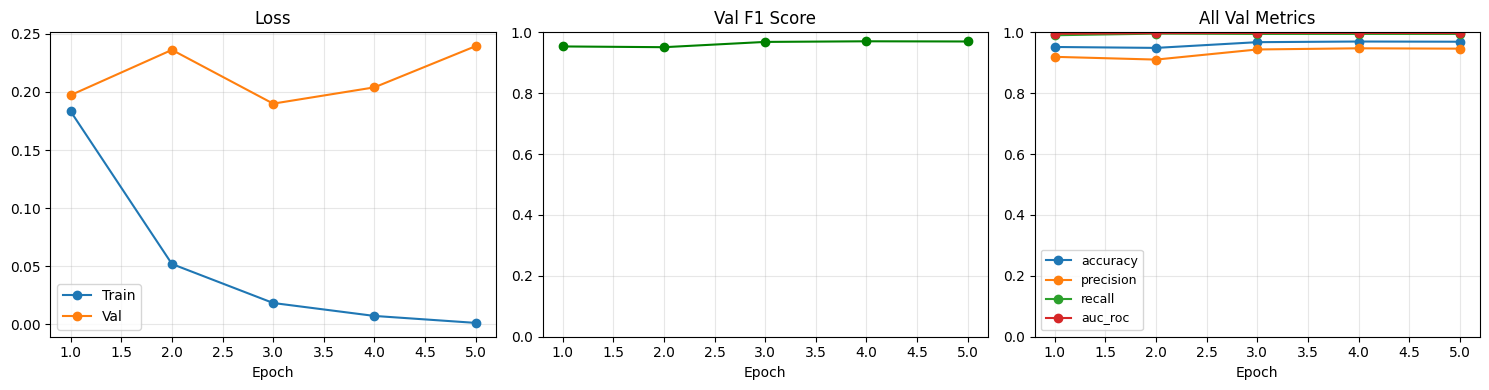


Epoch-by-epoch results:
 epoch  train_loss  val_loss       f1  accuracy  auc_roc
     1    0.183207  0.197299 0.953651  0.951855 0.995351
     2    0.051786  0.236283 0.951181  0.948887 0.997415
     3    0.018184  0.189957 0.968539  0.967683 0.997857
     4    0.007028  0.203989 0.970565  0.969827 0.998095
     5    0.001035  0.239480 0.969941  0.969167 0.997583


In [ ]:
# 8. Training History

# %%
import matplotlib.pyplot as plt

hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(hist_df["epoch"], hist_df["train_loss"], "o-", label="Train")
axes[0].plot(hist_df["epoch"], hist_df["val_loss"], "o-", label="Val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1
axes[1].plot(hist_df["epoch"], hist_df["f1"], "o-", color="green")
axes[1].set_title("Val F1 Score")
axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

# All metrics
for m in ["accuracy", "precision", "recall", "auc_roc"]:
    axes[2].plot(hist_df["epoch"], hist_df[m], "o-", label=m)
axes[2].set_title("All Val Metrics")
axes[2].set_xlabel("Epoch")
axes[2].set_ylim(0, 1)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print table
print("\nEpoch-by-epoch results:")
print(hist_df[["epoch", "train_loss", "val_loss", "f1", "accuracy", "auc_roc"]].to_string(index=False))


In [ ]:
# 9. Test on Sample Reviews

# %%
@torch.no_grad()
def predict_review(text, model, tokenizer):
    model.eval()
    enc = tokenizer(text, max_length=512, padding="max_length", truncation=True, return_tensors="pt")
    ids = enc["input_ids"].to(DEVICE)
    mask = enc["attention_mask"].to(DEVICE)

    out = model(ids, attention_mask=mask)
    probs = torch.softmax(out.logits, dim=1)

    genuine_prob = probs[0, 0].item()
    fake_prob = probs[0, 1].item()
    score = round(genuine_prob * 10, 1)

    if score >= 8:
        label = "✅ Likely Genuine"
    elif score >= 5:
        label = "⚠️ Uncertain"
    else:
        label = "🚨 Likely Fake"

    return {"score": score, "label": label, "fake_prob": fake_prob, "genuine_prob": genuine_prob}


# Test reviews
tests = [
    "I bought this blender 3 months ago and it still works great. Motor is quiet, blends smoothly. Worth every penny.",
    "AMAZING PRODUCT!!! BEST THING EVER BUY NOW!!! 5 STARS!!!",
    "It's okay. Does what it says but the build quality could be better for the price point.",
    "I received this product for free in exchange for my honest review. That said it is truly the best product I have ever used in my entire life and I would recommend it to everyone.",
    "Stopped working after 2 weeks. Customer service was unhelpful. Would not recommend. Returning it.",
]

print("Sample predictions with trained model:\n")
for i, text in enumerate(tests):
    r = predict_review(text, model, tokenizer)
    preview = text[:70] + "..." if len(text) > 70 else text
    print(f"  {i+1}. \"{preview}\"")
    print(f"     Score: {r['score']}/10  {r['label']}  (fake: {r['fake_prob']:.1%})\n")


Sample predictions with trained model:

  1. "I bought this blender 3 months ago and it still works great. Motor is ..."
     Score: 10.0/10  ✅ Likely Genuine  (fake: 0.0%)

  2. "AMAZING PRODUCT!!! BEST THING EVER BUY NOW!!! 5 STARS!!!"
     Score: 10.0/10  ✅ Likely Genuine  (fake: 0.0%)

  3. "It's okay. Does what it says but the build quality could be better for..."
     Score: 10.0/10  ✅ Likely Genuine  (fake: 0.0%)

  4. "I received this product for free in exchange for my honest review. Tha..."
     Score: 10.0/10  ✅ Likely Genuine  (fake: 0.0%)

  5. "Stopped working after 2 weeks. Customer service was unhelpful. Would n..."
     Score: 10.0/10  ✅ Likely Genuine  (fake: 0.0%)



In [ ]:
# 10. Download Trained Model
# Downloads the model to your computer.
# Then put the `bert_best/` folder inside `genzon/model/checkpoints/`

# %%
import shutil

# Zip the model folder
shutil.make_archive("bert_best", "zip", ".", "bert_best")

# Check size
zip_size = os.path.getsize("bert_best.zip") / (1024 * 1024)
print(f"Model zip size: {zip_size:.1f} MB")

# List files
print("\nModel files:")
for f in sorted(os.listdir("bert_best")):
    fsize = os.path.getsize(f"bert_best/{f}") / (1024 * 1024)
    print(f"  {f} ({fsize:.1f} MB)")

# Download
from google.colab import files
print("\n📥 Downloading bert_best.zip...")
files.download("bert_best.zip")